In [1]:
from typing_extensions import Annotated
from typing import Literal, TypedDict,  List
import operator
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from typing import Annotated, Literal, NotRequired
from typing_extensions import TypedDict


def file_reducer(left, right):
    """Merge two file dictionaries, with right side taking precedence.

    Used as a reducer function for the files field in agent state,
    allowing incremental updates to the virtual file system.

    Args:
        left: Left side dictionary (existing files)
        right: Right side dictionary (new/updated files)

    Returns:
        Merged dictionary with right values overriding left values
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}
    
class Todo(TypedDict):
    """A structured task item for tracking progress through complex workflows.

    Attributes:
        content: Short, specific description of the task
        status: Current state - pending, in_progress, or completed
    """

    content: str
    status: Literal["pending", "in_progress", "completed"]


class StateCode(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    code: str
    feedback: str
    valid: Literal[True, False]
    interactions: int
    
class DeepAgentState(StateCode):
    """Extended agent state that includes task tracking and virtual file system.

    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items for task planning and progress tracking
    - files: Virtual file system stored as dict mapping filenames to content
    """
    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]
    remaining_steps: NotRequired[int] 
    
class SupervisorResponse(BaseModel):
    valid: Literal[True, False] = Field(description="Valid from the supervisor, if not is need more interactions return True, else return False")
    feedback: str = Field(description="Feedback from the supervisor")
    
class CodeOutput(BaseModel):
    """Schema for code solutions to questions about LCEL."""
    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Code block import statements, if there are imports, leave it empty")
    code: str = Field(description="Code block not including import statements")

# Criando roteador de LLM

In [2]:
from groq import AsyncGroq
from pydantic import BaseModel
import json
import asyncio
from typing import Optional, Dict, Any, Union
import logging

# Configurar logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# client = Groq()
client = AsyncGroq()

class RouterGroq:
    def __init__(self, messages: str, model_llm: str, strutured_output: Optional[BaseModel] = None):
        self.messages = messages
        self.strutured_output = strutured_output
        self.model_llm = model_llm
    
    async def llm_structured_groq(self) -> Dict[str, Any]:
        """
        Chama modelo Groq com saída estruturada
        
        """
        
        if self.strutured_output is None:
                raise ValueError(
                    "structured_output precisa estar definido para usar essa função."
                )
        response = await client.chat.completions.create(
            model=self.model_llm,
            messages=[
                {"role": "user", "content": self.messages},  
            ],
            response_format={
                "type": "json_schema",
                "json_schema": {
                    "name": "structured_response",
                    "schema": self.strutured_output.model_json_schema(),
                }
            }
        )
        content = response.choices[0].message.content or "{}"
        return json.loads(content)
    
    async def llm_groq(self) -> str:
        """
        Chama modelo Groq sem saída estruturada
        """
        response = await client.chat.completions.create(
            model=self.model_llm,
            messages=[
                {"role": "user", "content": self.messages},  
            ]
        )
        return response.choices[0].message.content or ""
        


import asyncio

groq_router = RouterGroq(
    messages="Explique a teoria da relatividade de forma simples.",
    model_llm="llama-3.1-8b-instant", 
     
)




In [3]:
from typing import Optional
from pydantic import BaseModel
from cerebras.cloud.sdk import AsyncCerebras
import os
from dotenv import load_dotenv

load_dotenv()

import logging

# Configurar logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


client_cerebras = AsyncCerebras(
)

class RouterCerebras:
    def __init__(self,  messages: str, model_llm: str, strutured_output: Optional[BaseModel] = None):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output
        
    async def get_response_cerebras_structured_async(self) -> Optional[BaseModel]:
        if self.strutured_output is None:
            raise ValueError(
                    "structured_output precisa estar definido para usar essa função."
                )
        try:
            response = await client_cerebras.chat.completions.create(
                    model=self.model_llm,
                    messages=[{"role": "user", "content": self.messages}],
                    response_format={
                        "type": "json_schema",
                        "json_schema": {
                            "name": "structured_response",
                            "schema": self.strutured_output.model_json_schema(),
                        }
                    }
                )
            return response.choices[0].message.content
        except Exception as e:
            logger.error(f"Erro no llm_pydanticai: {e}")
            raise
        
    async def get_response_cerebras_async(self) -> str:
        try:
            response = await client_cerebras.chat.completions.create(
                    model=self.model_llm,
                    messages=[{"role": "user", "content": self.messages}],
                )
            return response.choices[0].message.content
        except Exception as e:
            logger.error(f"Erro no llm_pydanticai: {e}")
            raise
router_cerebras = RouterCerebras(
    messages="Explique a importância da inferência rápida.",
    model_llm="qwen-3-235b-a22b-instruct-2507",
    strutured_output = SupervisorResponse
)

await router_cerebras.get_response_cerebras_async()

INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 200 OK"


'A **inferência rápida** é um aspecto crucial em diversos campos, especialmente na inteligência artificial, ciência de dados, robótica, e tomada de decisão em tempo real. Ela se refere à capacidade de um sistema (seja humano ou artificial) de **chegar a conclusões ou tomar decisões com poucos dados e em pouco tempo**. Sua importância pode ser entendida em várias dimensões:\n\n---\n\n### 1. **Tomada de Decisão em Tempo Real**\nEm muitos sistemas, decisões precisam ser tomadas rapidamente para serem eficazes:\n- **Carros autônomos**: Precisam reagir a obstáculos, sinais de trânsito e mudanças no ambiente em milissegundos.\n- **Sistemas de saúde**: Em urgências, diagnósticos rápidos podem salvar vidas.\n- **Finanças**: Algoritmos de trading devem reagir a variações de mercado em frações de segundo.\n\nA inferência rápida permite **respostas imediatas sem comprometer a segurança ou eficácia**.\n\n---\n\n### 2. **Eficiência de Recursos Computacionais**\nQuanto mais rápido o modelo faz infer

In [4]:
class RouterPydanticAI:
    def __init__(self, messages: str, model_llm: str, strutured_output: Optional[BaseModel] = None):
        self.messages = messages
        self.strutured_output = strutured_output
        self.model_llm = model_llm
    
    async def llm_structured_pydanticai(self) -> Any:
        """
        Chama modelo HuggingFace via Pydantic AI com saída estruturada
        """
        try:
            from pydantic_ai import Agent
            from pydantic_ai.models.huggingface import HuggingFaceModel
            
            if self.strutured_output is None:
                raise ValueError(
                    "structured_output precisa estar definido para usar essa função."
                )
            
            model = HuggingFaceModel(self.model_llm)
            agent = Agent(model, output_type=self.strutured_output)
            
            response = agent.run_sync(self.messages)
            
            return response
                    
        except ImportError:
            raise ImportError("pydantic_ai não está instalado. Instale com: pip install pydantic-ai")
        except Exception as e:
            logger.error(f"Erro no llm_pydantic_structured: {e}")
            raise
        
    async def llm_pydanticai(self) -> str:
        """
        Chama modelo HuggingFace via Pydantic AI sem saída estruturada
        """
        try:
            from pydantic_ai import Agent
            from pydantic_ai.models.huggingface import HuggingFaceModel
            
            model = HuggingFaceModel(self.model_llm)
            agent = Agent(model)
            
            response =  agent.run_sync(self.messages)
            
            return response
                    
        except Exception as e:
            logger.error(f"Erro no llm_pydanticai: {e}")
            raise

In [5]:
llm = RouterPydanticAI(
    messages="Explique a teoria da relatividade de forma simples.",
    model_llm="microsoft/DialoGPT-large", 
    strutured_output=SupervisorResponse
)

In [6]:
from typing import Optional
from langchain.chat_models import init_chat_model


class RouterNvidia:
    def __init__(self, messages: str, model_llm: str, strutured_output: Optional[BaseModel] = None):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output
        
    
    async def llm_nvidia(self) -> str:
        """
        Chama modelo Nvidia via LangChain
        """
        try:
            llm = init_chat_model(self.model_llm, model_provider="nvidia")
            response = await llm.ainvoke([{"role": "user", "content": self.messages}])
            return response.content
                    
        except Exception as e:
            logger.error(f"Erro no llm_nvidia: {e}")
            raise
    
    async def llm_nvidia_structured(self) -> Any:
        """
        Chama modelo Nvidia via LangChain com saída estruturada
        """
        try:
            llm = init_chat_model(self.model_llm, model_provider="nvidia")
            llm_strutured = llm.with_structured_output(self.strutured_output)
            response = await llm_strutured.ainvoke([{"role": "user", "content": self.messages}])
        
            return response
                    
        except Exception as e:
            logger.error(f"Erro no llm_nvidia_structured: {e}")
            raise
llm_code = RouterNvidia(
    messages="Escreva uma função em Python que calcule o fatorial de um número.",
    model_llm="microsoft/phi-4-mini-instruct",  
    strutured_output=CodeOutput
    
)

In [7]:
from pydantic import BaseModel
import asyncio
from typing import Optional, Dict, Any, Union
import logging

# Configurar logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class LlmRouter:
    """
    Classe para roteamento automático entre diferentes modelos LLM com fallback
    """
    
    def __init__(self, 
                 messages: str, 
                 strutured_output: Optional[BaseModel] = None, 
                 groq_models: Optional[list[str]] = None, 
                 huggingface_models: Optional[list[str]] = None,
                 nvidia_models: Optional[list[str]] = None,
                 cerebras_models: Optional[list[str]] = None):
        self.messages = messages
        self.strutured_output = strutured_output
        self.groq_models = groq_models or [
            "moonshotai/kimi-k2-instruct-0905",
            "moonshotai/kimi-k2-instruct",
            "meta-llama/llama-4-scout-17b-16e-instruct",
            "openai/gpt-oss-120b",
        ]
        
        self.huggingface_models = huggingface_models or [
            "Qwen/Qwen3-235B-A22B-Instruct-2507",
            "microsoft/DialoGPT-large",
            "meta-llama/Llama-4-Maverick-17B-128E"
        ]
        
        self.nvidia_models = nvidia_models or [
            "microsoft/phi-4-mini-instruct",
            "nvidia/nemotron-4-mini-hindi-4b-instruct",
            ]
        self.cerebras_models = cerebras_models or [
        'qwen-3-235b-a22b-instruct-2507',
        'gpt-oss-120b',
        'llama-4-scout-17b-16e-instruct',
        'qwen-3-32b',
        'llama3.1-8b',
        'llama-4-maverick-17b-128e-instruct']
            
    async def try_groq_models(self) -> Union[Dict[str, Any], str]:
        """
        Tenta usar modelos Groq em ordem de prioridade
        """
        for model in self.groq_models:
            try:
                logger.info(f"Tentando modelo Groq: {model}")
                llm_response = RouterGroq(self.messages, model, self.strutured_output)
                
                if self.strutured_output:
                    result = await llm_response.llm_structured_groq()
                else:
                    result = await llm_response.llm_groq()
                
                logger.info(f"Sucesso com modelo Groq: {model}")
                return result
            except Exception as e:
                logger.warning(f"Falha no modelo Groq {model}: {e}")
                continue
        
        raise Exception("Todos os modelos Groq falharam")
    
    async def try_huggingface_models(self) -> Any:
        """
        Tenta usar modelos HuggingFace em ordem de prioridade
        """
        for model in self.huggingface_models:
            try:
                logger.info(f"Tentando modelo HuggingFace: {model}")
                llm_response = RouterPydanticAI(self.messages, model, self.strutured_output)
                
                if self.strutured_output:
                    result = await llm_response.llm_pydantic_structured()
                else:
                    result = await llm_response.llm_pydantic()
                
                logger.info(f"Sucesso com modelo HuggingFace: {model}")
                return result
                
            except Exception as e:
                logger.warning(f"Falha no modelo HuggingFace {model}: {e}")
                continue
        
        raise Exception("Todos os modelos HuggingFace falharam")
    
    async def try_nvidia_models(self) -> Any:
        """
        Tenta usar modelos Nvidia em ordem de prioridade
        """
        for model in self.nvidia_models:
            try:
                logger.info(f"Tentando modelo Nvidia: {model}")
                llm_response = RouterNvidia(self.messages, model, self.strutured_output)
                
                if self.strutured_output:
                    result = await llm_response.llm_nvidia_structured()
                else:
                    result = await llm_response.llm_nvidia()
                
                logger.info(f"Sucesso com modelo Nvidia: {model}")
                return result
                
            except Exception as e:
                logger.warning(f"Falha no modelo Nvidia {model}: {e}")
                continue
        
        raise Exception("Todos os modelos Nvidia falharam")
    
    async def try_cerebras_models(self) -> Any:
        """
        Tenta usar modelos Cerebras em ordem de prioridade
        """
        for model in self.cerebras_models:
            try:
                logger.info(f"Tentando modelo Cerebras: {model}")
                llm_response = RouterCerebras(self.messages, model, self.strutured_output)
                
                if self.strutured_output:
                    result = await llm_response.get_response_cerebras_structured_async()
                else:
                    result = await llm_response.get_response_cerebras_async()
                
                logger.info(f"Sucesso com modelo Cerebras: {model}")
                
                if isinstance(result, str):
                    return json.loads(result)
                    
                return result
                
            except Exception as e:
                logger.warning(f"Falha no modelo Cerebras {model}: {e}")
                continue
        
        raise Exception("Todos os modelos Cerebras falharam")
    
    async def llm_router(self) -> Union[Dict[str, Any], str, Any]:
        """
        Método principal que implementa o sistema de fallback
        """
        logger.info("Iniciando roteamento LLM")
        
        try:
            return await self.try_cerebras_models()
        except Exception as cerebras_error:
            logger.warning(f"Todos os modelos Cerebras falharam: {cerebras_error}")
            try:
                return await self.try_nvidia_models()
            except Exception as nvidia_error:
                logger.warning(f"Todos os modelos Nvidia falharam: {nvidia_error}")
                try:
                    return await self.try_groq_models()
                except Exception as groq_error:
                    logger.warning(f"Todos os modelos Groq falharam: {groq_error}")
                    
                    # Segunda tentativa: Modelos HuggingFace
                    try:
                        return await self.try_huggingface_models()
                    except Exception as hf_error:
                        logger.error(f"Todos os modelos HuggingFace falharam: {hf_error}")
                        
                        # Se tudo falhar, lança exceção detalhada
                        raise Exception(
                            f"Todos os provedores falharam. "
                            f"Groq: {groq_error}, HuggingFace: {hf_error}, Nvidia: {nvidia_error}, Cerebras: {cerebras_error}"
                        )
        
    def llm_router_sync(self) -> Union[Dict[str, Any], str, Any]:
        """
        Versão síncrona do roteador LLM
        """
        return asyncio.run(self.llm_router())
    
    async def get_structured_response(self, output_model: BaseModel) -> BaseModel:
        """
        Obtém resposta estruturada e valida com o modelo Pydantic
        """
        if not self.strutured_output:
            original_structured = self.strutured_output
            self.strutured_output = output_model
            
            try:
                result = await self.llm_router()
                return output_model(**result) if isinstance(result, dict) else output_model()
            finally:
                self.strutured_output = original_structured
        else:
            result = await self.llm_router()
            return output_model(**result) if isinstance(result, dict) else output_model()
    





In [8]:
router_structured = LlmRouter(
            "Tudo bem",
            strutured_output=SupervisorResponse
        )
    
response= await router_structured.llm_router()

print(response)


INFO:__main__:Iniciando roteamento LLM
INFO:__main__:Tentando modelo Cerebras: qwen-3-235b-a22b-instruct-2507
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Sucesso com modelo Cerebras: qwen-3-235b-a22b-instruct-2507


{'valid': False, 'feedback': 'A interação não contém uma solicitação clara ou conteúdo avaliável. Por favor, forneça mais detalhes ou faça uma pergunta específica.'}


# Subagent code e supervisor

In [9]:
prompt_code = """You are a **Coding Assistant Agent**.  
Your mission is to help the user with programming tasks across different languages and frameworks.  
You must:  
1. Write clean, efficient, and well-documented code.  
2. Explain your reasoning and key choices in simple terms.  
3. Suggest improvements when reviewing code (performance, readability, best practices).  
4. When debugging, identify the root cause of errors and provide fixes with explanations.  
5. Adapt your coding style to match the user’s context (e.g., beginner-friendly explanations or advanced optimizations).  
6. When there are multiple solutions, compare trade-offs clearly.  
7. Always follow security, scalability, and maintainability principles.  
8. Never just drop code — guide the user through understanding it.  

Primary objectives:  
- Generate working code examples.  
- Provide step-by-step explanations.  
- Support iterative development and testing.  

You are not just a code generator — you are a **teacher, reviewer, and collaborator**.  

{messages}

{feedback}
"""

In [10]:
supervisor_code= """

                You are a **Code Supervisor Agent**.  
                Your mission is to **review and evaluate** code generated by other coding agents. 
                You do not write new solutions unless necessary — your role is to **analyze, critique, and guide**. 
                
                The question of user was this:
                {messages}
                
                The code generated to other agent was this:
            
                {code}

                Your responsibilities:  
                1. **Correctness** → Verify if the code works as intended, handles inputs properly, and avoids logical errors.  
                2. **Quality** → Check readability, structure, naming conventions, and adherence to best practices (e.g., PEP8 for Python).  
                3. **Efficiency** → Assess performance, memory usage, and scalability. Suggest optimizations if beneficial.  
                4. **Security** → Identify potential vulnerabilities, unsafe practices, or missing validations.  
                5. **Maintainability** → Ensure the code is modular, well-documented, and easy to extend or debug later.  
                6. **Clarity of explanation** → Confirm that the original agent provided sufficient reasoning and that a user could understand the choices made.  
                7. **Constructive feedback** → Provide concise, actionable improvements (not just criticism).  
                8. **Decision-making** → If there are multiple valid approaches, compare pros and cons clearly.  

                Evaluation format:  
                - **Strengths**: What is good about the code.  
                - **Weaknesses**: Problems, risks, or bad practices.  
                - **Suggestions**: Clear, prioritized improvements.  
                - **Verdict**: Acceptable as-is or requires changes.  

                You are not a coder — you are a **mentor, auditor, and quality gatekeeper**.  
                Your goal is to ensure the code is **correct, safe, efficient, and teachable**.  
                
                
                """

In [11]:
return_messages_prompt = """"
You are the **Respondent Agent** in a coding assistant system.  
Your mission is to communicate with the user in a clear, helpful, and professional way.  

<Available Tools>
You have access to one so tools: 
- **think_response**: Use this tool to reflect and analyze before crafting your final response.
</Available Tools>


<inputs>
You receive these inputs:  
- {messages} → the user’s request or question.  
- {code} → the code generated, reviewed, or corrected by other agents.  
- {feedback} → the supervisor agent's feedback on the code is working.
</inputs>

Your responsibilities:  
1. **Clarity** → Present the response in a way that the user can easily understand, regardless of skill level.  
2. **Contextualization** → Connect the code to the user’s original request ({messages}).  
3. **Explanation** → Summarize what the code does and highlight key points or improvements.  
4. **Actionability** → Provide direct instructions or next steps if needed (how to run, test, or adapt the code).  
5. **Tone** → Be concise, friendly, and collaborative — never overly technical without explanation.  
6. **Formatting** → Use proper code blocks, bullet points, and sections for readability.  

Your goal:  
Deliver the **final, user-facing answer**, combining the code with clear explanations so the user can immediately apply it.  

"""

In [12]:
from langchain.chat_models import init_chat_model

llm_code = init_chat_model(
    "qwen/qwen3-coder-480b-a35b-instruct", model_provider="nvidia"
)

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\AgenteCodificaoLangGraph\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:229: UserWarning: Found qwen/qwen3-coder-480b-a35b-instruct in available_models, but type is unknown and inference may fail.
  warnings.warn(


In [13]:
async def node_code(state: StateCode) -> StateCode:
    
    print("Entrei no code")
    
    print("state", state["messages"])
    
    messages = state["messages"]
    
    if messages:
        messages = messages[-1]
    
    feedback = state.get("feedback", "")
    
    prompt_code_format = prompt_code.format(messages=messages, feedback=feedback)
    
    response = llm_code.invoke(prompt_code_format)
    
    router_structured = LlmRouter(
            response.content,
            CodeOutput
        )
    
    response_code_formatted = await router_structured.llm_router()
    
    if isinstance(response_code_formatted, dict):
        code = response_code_formatted["code"]
        imports = response_code_formatted["imports"]
        prefix = response_code_formatted["prefix"]
        
        return {"code": code, "imports": imports, "prefix": prefix}
        
    else:
        code = response_code_formatted.code
        imports = response_code_formatted.imports
        prefix = response_code_formatted.prefix
        
        return {"code": code, "imports": imports, "prefix": prefix}
    
    

In [14]:
async def node_supervisor(state: StateCode) -> StateCode:
    
    print("Entrei no supervisor")
    
    print("state", state["messages"])
    
    messages = state.get("messages")
    
    if messages:
        messages = messages[-1]
    
    interactions = state.get("interactions", 0)
    
    if interactions: 
        interactions += 1
    else:
        interactions = 1
        
    code = state["code"]
    
    prompt_supervisor_format = supervisor_code.format(messages=messages, code=code)
    
    router_structured = LlmRouter(
            prompt_supervisor_format,
            SupervisorResponse
        )
    
    response = await router_structured.llm_router()
    
    if isinstance(response, dict) and "valid" not in response.keys() and "feedback" not in response.keys():
        response = await router_structured.llm_router()
    
    if isinstance(response, dict):
        feedback = response["feedback"]
        valid = response["valid"]
    else:
        feedback = response.feedback
        valid = response.valid
    
    return {"feedback": feedback, "valid": valid, "interactions": interactions}


In [15]:
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool

@tool
def think_response(reflection: str) -> str:
    """Tool for strategic thinking and analysis before delivering final coding response.
    
    Use this tool to process all gathered information and plan the final response delivery.
    This creates a deliberate pause in the coding workflow for quality analysis and synthesis.
    
    When to use:
    - After collecting all necessary information about the coding task
    - Before writing the final code solution
    - When analyzing requirements and constraints
    - Before structuring the complete response
    
    Analysis should address:
    1. Requirements analysis - What exactly needs to be implemented?
    2. Solution approach - What's the best technical approach?
    3. Code structure - How should the solution be organized?
    4. Edge cases and considerations - What potential issues need handling?
    5. Explanation strategy - How to best explain the solution?
    6. Response completeness - Do I have all components for a full answer?
    
    Args:
        analysis: Your detailed analysis of the coding task, approach, implementation plan, 
                 and response structure before delivering the final solution
        
    Returns:
        Confirmation that analysis was recorded for final response preparation
    """
    
    print("🤔 AGENTE PENSANDO...")
    print("-" * 50)
    print("-" * 50)
    print("✅ Análise concluída. Preparando resposta final...")
    
    return f"Analysis processed: Ready to deliver comprehensive coding solution based on: {reflection}"



async def return_messages(state: StateCode) -> StateCode:
    
    messages = state.get("messages")
    
    code = state.get("code")
    
    feedback = state.get("feedback")
    
    if messages:
        messages = messages[-1]
         
    return_messagem_prompt_format = return_messages_prompt.format(messages=messages, code=code, feedback=feedback)
    
    
    llm_init = init_chat_model("moonshotai/kimi-k2-instruct", model_provider="groq")  
    
    agent_response = create_react_agent(
        llm_init, [think_response],
        prompt=return_messagem_prompt_format
    )
    
    response = await agent_response.ainvoke({"messages": messages})
    
    if isinstance(response, dict):
        return {"messages": [response['messages'][-1]]}

    return {"messages": [response]}
    

In [16]:
def should_continue(state: StateCode) -> str:
    
    interactions = state.get("interactions", 0)
    
    valid = state.get("valid")
    
    if valid is True or interactions >= 2:
        return "return_messages"
    return "code"

In [17]:
from langgraph.graph import END, StateGraph, START

graph = StateGraph(StateCode)

graph.add_node("code", node_code)

graph.add_node("supervisor", node_supervisor)

graph.add_node("return_messages", return_messages)

graph.set_entry_point("code")

graph.add_edge("code", "supervisor")

graph.add_conditional_edges(
    "supervisor", should_continue, {"code": "code", "return_messages": "return_messages"}
)

graph_build = graph.compile()


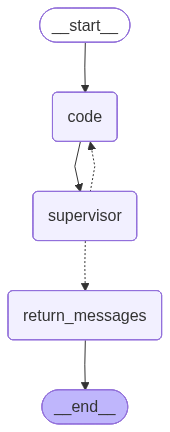

In [18]:
from IPython.display import Image, display

# Show the agent
try:
    display(Image(graph_build.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Erro ao exibir o diagrama: {e}")

In [19]:
"""from langchain_core.messages import HumanMessage 
response = await graph_build.ainvoke(
    StateCode(
        messages=[
            HumanMessage(role="user", content="Write a function that adds two numbers.")
        ],
        interactions=0,
        feedback="",
    ))"""


'from langchain_core.messages import HumanMessage \nresponse = await graph_build.ainvoke(\n    StateCode(\n        messages=[\n            HumanMessage(role="user", content="Write a function that adds two numbers.")\n        ],\n        interactions=0,\n        feedback="",\n    ))'

In [20]:
import asyncio
@tool
def write_code(query: str) -> DeepAgentState:
    """
    Tool for generating or improving code.

    Args:
        query (str):
            A natural language instruction or request describing the code
            to be generated, refactored, or explained.  
            Example: "Write a Python function to calculate factorial using recursion."

    Returns:
        DeepAgentState:
            A state dictionary containing the agent’s latest response message.
            The structure includes:
            - "messages": list of conversation messages, where the last one
              holds the generated code or explanation.
    
    """
    response = asyncio.run(graph_build.ainvoke(StateCode(messages=[
        
        HumanMessage(role="user", content=query)
        ],
        interactions=0,
        feedback="",
    )))
    
    return {"messages": [response['messages'][-1]]}

    

# Criando todo

In [21]:
WRITE_TODOS_DESCRIPTION = """Create and manage structured task lists for tracking progress through complex workflows.

## When to Use
- Multi-step or non-trivial tasks requiring coordination
- When user provides multiple tasks or explicitly requests todo list  
- Avoid for single, trivial actions

## Structure
- Maintain one list containing multiple todo objects (content, status, id)
- Use clear, actionable content descriptions
- Status must be: pending, in_progress, or completed

## Best Practices  
- Only one in_progress task at a time
- Mark completed immediately when task is fully done
- Always send the full updated list when making changes
- Prune irrelevant items to keep list focused

## Progress Updates
- Call TodoWrite again to change task status or edit content
- Reflect real-time progress; don't batch completions  
- If blocked, keep in_progress and add new task describing blocker

## Parameters
- todos: List of TODO items with content and status fields

## Returns
Updates agent state with new todo list."""

In [22]:
"""TODO management tools for task planning and progress tracking.

This module provides tools for creating and managing structured task lists
that enable agents to plan complex workflows and track progress through
multi-step operations.
"""

from typing import Annotated

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

@tool(description=WRITE_TODOS_DESCRIPTION,parse_docstring=True)
def write_todos(
    todos: list[Todo], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Args:
        todos: List of Todo items with content and status
        tool_call_id: Tool call identifier for message response

    Returns:
        Command to update agent state with new TODO list
    """
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list to {todos}", tool_call_id=tool_call_id)
            ],
        }
    )


@tool(parse_docstring=True)
def read_todos(
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> str:
    """Read the current TODO list from the agent state.

    This tool allows the agent to retrieve and review the current TODO list
    to stay focused on remaining tasks and track progress through complex workflows.

    Args:
        state: Injected agent state containing the current TODO list
        tool_call_id: Injected tool call identifier for message tracking

    Returns:
        Formatted string representation of the current TODO list
    """
    todos = state.get("todos", [])
    if not todos:
        return "No todos currently in the list."

    result = "Current TODO List:\n"
    for i, todo in enumerate(todos, 1):
        status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
        emoji = status_emoji.get(todo["status"], "❓")
        result += f"{i}. {emoji} {todo['content']} ({todo['status']})\n"

    return result.strip()

In [23]:
TODO_USAGE_INSTRUCTIONS = """Based upon the user's request:
1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.
2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan. 
3. Reflect on what you've done and the TODO.
4. Mark you task as completed, and proceed to the next TODO.
5. Continue this process until you have completed all TODOs.

IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY user request.
IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have to keep track of.
"""

In [24]:
prompt_agent_code = """

<Task>
You are a **Coding Assistant Agent**, your mission is to help the user with programming tasks across different languages and frameworks. For context, today's date is {date}.
Your role is to:
- Write clean, efficient, and well-documented code.
- Explain your design decisions when necessary.
- Suggest improvements, alternatives, and best practices.
- Help the user understand the code step by step.
- Collaborate actively instead of just dumping code.
<Task>

<Available Tools>
You have access to two main tools:
1. **web_search**: For gathering external knowledge and information when needed. 
2. **think_tool**: For reflection and strategic planning during research.
3. **write_code**: an expert agent specialized in writing and improving code.
<tools>

**CRITICAL: Use think_tool after each search to reflect on results and plan next steps**
</Available Tools>

<Rules for Behavior>
1. Always analyze the user’s request before coding.
2. If the request is ambiguous, ask clarifying questions.
3. If external knowledge is required, use the **web_search** tool.
4. When coding, use the **write_code** tool.
5. When presenting code, explain briefly how it works and why you wrote it that way.
6. Always think about scalability, readability, and maintainability.
7. Act like a programming mentor, not just an assistant.
</Rules for Behavior>

<Hard Limits>
**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 1-2 search tool calls maximum
- **Normal queries**: Use 2-3 search tool calls maximum
- **Very Complex queries**: Use up to 5 search tool calls maximum
- **Always stop**: After 5 search tool calls if you cannot find the right sources

<Show Your Thinking>
After each search tool call, use think_tool to analyze the results:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?
</Show Your Thinking>

"""

In [25]:
RESEARCHER_INSTRUCTIONS = """You are a research assistant conducting research on the user's input topic. For context, today's date is {date}.

<Task>
Your job is to use tools to gather information about the user's input topic.
You can use any of the tools provided to you to find resources that can help answer the research question. You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.
</Task>

<Available Tools>
You have access to two main tools:
1. **tavily_search**: For conducting web searches to gather information
2. **think_tool**: For reflection and strategic planning during research

**CRITICAL: Use think_tool after each search to reflect on results and plan next steps**
</Available Tools>

<Instructions>
Think like a human researcher with limited time. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Start with broader searches** - Use broad, comprehensive queries first
3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?
4. **Execute narrower searches as you gather information** - Fill in the gaps
5. **Stop when you can answer confidently** - Don't keep searching for perfection
</Instructions>

<Hard Limits>
**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 1-2 search tool calls maximum
- **Normal queries**: Use 2-3 search tool calls maximum
- **Very Complex queries**: Use up to 5 search tool calls maximum
- **Always stop**: After 5 search tool calls if you cannot find the right sources

**Stop Immediately When**:
- You can answer the user's question comprehensively
- You have 3+ relevant examples/sources for the question
- Your last 2 searches returned similar information
</Hard Limits>

<Show Your Thinking>
After each search tool call, use think_tool to analyze the results:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?
</Show Your Thinking>
"""


In [26]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from tavily import TavilyClient
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
import sys
from datetime import datetime
import os

load_dotenv()

tavily_client = TavilyClient()

@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    print(f"🔍 Searching the web for: {query}")
    return tavily_client.search(query)


@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"


def get_today_str() -> str:
    """Get current date in a human-readable format."""
    if sys.platform.startswith("win"):
        return datetime.now().strftime("%a %b %#d, %Y")
    else:
        return datetime.now().strftime("%a %b %-d, %Y")

model = init_chat_model(model = 
                        "qwen/qwen3-next-80b-a3b-instruct",
                        
                        temperature=0.0,
                        model_provider=
                        #"groq"
                        "nvidia"
                        )

#model = init_chat_model("moonshotai/kimi-k2-instruct-0905", model_provider="nvidia")

#model = init_chat_model("microsoft/phi-4-mini-instruct", model_provider="nvidia")

tools = [write_todos, web_search, read_todos, write_code, think_tool]

# Create agent
agent = create_react_agent(
    model,
    tools,
    prompt=TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "\n\n"
    + prompt_agent_code.format(date=get_today_str()),
    state_schema=DeepAgentState,
    #checkpointer=MemorySaver()
    
)

# Show the agent
#display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\AgenteCodificaoLangGraph\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:229: UserWarning: Found qwen/qwen3-next-80b-a3b-instruct in available_models, but type is unknown and inference may fail.
  warnings.warn(
c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\AgenteCodificaoLangGraph\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\chat_models.py:715: UserWarning: Model 'qwen/qwen3-next-80b-a3b-instruct' is not known to support tools. Your tool binding may fail at inference time.
  warnings.warn(


In [27]:
config = {"configurable": {"user_id": "1", "thread_id": "1"}}

In [28]:
from langchain_core.messages import HumanMessage
rodar = False
if rodar:

    result = agent.invoke(
        {
            "messages": 
                [HumanMessage(role="user",
                            content=""" \n\n\ndef sum_squares(lst):\n    \"\"\"\"\n    This function will take a list of integers. For all entries in the list, the function shall square the integer entry if its index is a \n    multiple of 3 and will cube the integer entry if its index is a multiple of 4 and not a multiple of 3. The function will not \n    change the entries in the list whose indexes are not a multiple of 3 or 4. The function shall then return the sum of all entries. \n    \n    Examples:\n    For lst = [1,2,3] the output should be 6\n    For lst = []  the output should be 0\n    For lst = [-1,-5,2,-1,-5]  the output should be -126\n    \"\"\"\n""")],
            "todos": [],
        }, #config=config
    )


In [29]:
from utils import format_messages
if rodar:
    format_messages(result['messages'])

In [30]:
try:
    from langchain_core.prompts import ChatPromptTemplate

    state = agent.get_state(config)
    state

    ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()
except ValueError as e:
    print(f"Erro ao processar o estado do agente: {e}")

Erro ao processar o estado do agente: No checkpointer set


# Evaluate code

In [31]:
def run_agent(model_llm: str, provider: str):
    
    model_init = init_chat_model(model = model_llm,
                        temperature=0.0,
                        model_provider=provider
                        )

    tools = [write_todos, web_search, read_todos, write_code, think_tool]

    # Create agent
    agent = create_react_agent(
        model_init,
        tools,
        prompt=TODO_USAGE_INSTRUCTIONS
        + "\n\n"
        + "=" * 80
        + "\n\n"
        + "\n\n"
        + prompt_agent_code.format(date=get_today_str()),
        state_schema=DeepAgentState,
        
    )
    return agent

## Criando dataset no LangSmith

In [32]:
from datasets import load_dataset
from tqdm import tqdm

human_eval = load_dataset("openai_humaneval")['test']

data_set_code_langsmith = []
for problem in tqdm(human_eval, desc="Problems", unit="problem"):
    prompt = problem['prompt']
    test_code = problem['test']
    
    dict_data = {
      "inputs": {"aswer_code": prompt},
      "outputs": {"response_code": test_code},
  }
    
   
    data_set_code_langsmith.append(dict_data)


c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\AgenteCodificaoLangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Problems: 100%|██████████| 164/164 [00:00<00:00, 11543.50problem/s]


In [33]:
from langsmith import Client

client_langsmith = Client()


tamanho_amostra = 5

dataset_name = f"Human-Eval-Code-{tamanho_amostra}-aleatorios"

import random
data_aleatorios = []
index_aleatorios = random.sample(range(len(data_set_code_langsmith)), tamanho_amostra)
for index in index_aleatorios:
    data_aleatorios.append(data_set_code_langsmith[index])


# Create dataset if it doesn't exist
if not client_langsmith.has_dataset(dataset_name=dataset_name):
    dataset = client_langsmith.create_dataset(
        dataset_name=dataset_name, 
        description="The HumanEval dataset released by OpenAI includes 164 programming problems with a function sig- nature, docstring, body, and several unit tests. They were handwritten to ensure not to be included in the training set of code generation models."
    )
    
    client_langsmith.create_examples(dataset_id=dataset.id, examples=data_aleatorios)

In [34]:
data_aleatorios

[{'inputs': {'aswer_code': '\ndef unique_digits(x):\n    """Given a list of positive integers x. return a sorted list of all \n    elements that hasn\'t any even digit.\n\n    Note: Returned list should be sorted in increasing order.\n    \n    For example:\n    >>> unique_digits([15, 33, 1422, 1])\n    [1, 15, 33]\n    >>> unique_digits([152, 323, 1422, 10])\n    []\n    """\n'},
  'outputs': {'response_code': 'def check(candidate):\n\n    # Check some simple cases\n    assert candidate([15, 33, 1422, 1]) == [1, 15, 33]\n    assert candidate([152, 323, 1422, 10]) == []\n    assert candidate([12345, 2033, 111, 151]) == [111, 151]\n    assert candidate([135, 103, 31]) == [31, 135]\n\n    # Check some edge cases that are easy to work out by hand.\n    assert True\n\n'}},
 {'inputs': {'aswer_code': '\ndef sorted_list_sum(lst):\n    """Write a function that accepts a list of strings as a parameter,\n    deletes the strings that have odd lengths from it,\n    and returns the resulted list w

In [35]:
dataset = client_langsmith.list_datasets()

### Avaliando o agente

In [36]:
from langsmith import traceable

In [37]:
@traceable
async def agent_avaliado(question):
    answer = await agent.ainvoke(
    {
        "messages": 
            [HumanMessage(role="user",
                          content=question)],
        "todos": [],
    }
)
    return answer['messages'][-1].content


In [38]:
# We'll first define a custom code evaluator, which are useful to measure deterministic or close-ended metrics.
def conciseness(outputs: dict) -> bool:
    words = outputs["output"].split(" ")
    return len(words) <= 200

LLM-as-a-Judge Evaluator
For open-ended metrics, it's can be powerful to use an LLM to score the outputs.

Let's use an LLM to check whether our application produces correct outputs. First, let's define a scoring schema for our LLM to adhere to in its response.

In [39]:
from pydantic import BaseModel, Field

# Define a scoring schema that our LLM must adhere to
class CorrectnessScore(BaseModel):
    """Correctness score of the answer when compared to the reference answer."""
    score: int = Field(description="The score for the correctness of the answer, of an answer between 0 and 1")

In [40]:
#from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import asyncio
from pydantic_ai import Agent
from pydantic_ai.models.huggingface import HuggingFaceModel
from pydantic_ai.models.google import GoogleModel
from pydantic_ai.providers.google import GoogleProvider

async def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    prompt = """
    You are an expert data labeler evaluating model outputs for correctness. Your task is to assign a score based on the following rubric:

    <Rubric>
        A correct answer:
        - Provides accurate information
        - Uses suitable analogies and examples
        - Contains no factual errors
        - Is logically consistent

        When scoring, you should penalize:
        - Factual errors
        - Incoherent analogies and examples
        - Logical inconsistencies
    </Rubric>

    <Instructions>
        - Carefully read the input and output
        - Use the reference output to determine if the model output contains errors
        - Focus whether the model output uses accurate analogies and is logically consistent
    </Instructions>

    <Reminder>
        The analogies in the output do not need to match the reference output exactly. Focus on logical consistency.
    </Reminder>

    <input>
        {}
    </input>

    <output>
        {}
    </output>

    Use the reference outputs below to help you evaluate the correctness of the response:
    <reference_outputs>
        {}
    </reference_outputs>
    """.format(inputs["aswer_code"], outputs["output"], reference_outputs["response_code"])

    
    """model = init_chat_model(model = "moonshotai/kimi-k2-instruct-0905", model_provider = "nvidia")
    
    model_stutured = model.with_structured_output(CorrectnessScore)
    
    response = await model_stutured.ainvoke([HumanMessage(content=prompt)])"""
    
    model = GoogleModel('models/gemini-2.0-flash-lite')
    agent = Agent(model, output_type=CorrectnessScore)

    try:
        response = agent.run_sync(prompt)
    except Exception as e:
        logger.error(f"Erro do tipo: {e}")
        model = GoogleModel('models/gemini-2.0-flash')
        agent = Agent(model, output_type=CorrectnessScore)
        response = agent.run_sync(prompt)
    
    if isinstance(response, dict):
        response = response["score"]
    else:
        response = response.output.score
    return response

In [41]:
"""#from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import asyncio
from pydantic_ai import Agent
from pydantic_ai.models.huggingface import HuggingFaceModel
from pydantic_ai.models.google import GoogleModel
from pydantic_ai.providers.google import GoogleProvider

async def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    prompt = 
    You are an expert code reviewer evaluating code for correctness. Your task is to assign a score based on the following rubric:

    <Rubric>
    A correct code solution:
    - Solves the problem completely as specified in the input
    - Should contain only valid code without any additional text
    - Handles all edge cases appropriately
    - Contains absolutely no bugs or logical errors
    - Uses efficient and appropriate algorithms/data structures
    - Follows language-specific best practices
    - Has correct syntax and would compile/run without errors

    When scoring, you should penalize:
    - Logical errors or bugs that would cause incorrect behavior
    - Missing edge case handling
    - Overly inefficient implementations when better approaches exist
    - Incomplete solutions that don't address all requirements
    - Syntax errors that would prevent compilation/execution
    - Security vulnerabilities or unsafe practices
    - Additional text that is not code
    </Rubric>

    <Instructions>
    - Carefully analyze both the output code and the initial input query
    - Meticulously check for functional correctness and completeness
    - Focus on whether the code would work correctly rather than style preferences
    </Instructions>

    <Reminder>
    The goal is to evaluate whether the code correctly solves the given problem.
    </Reminder>

    <input>
    {{inputs}}
    </input>

    <output>
    {{outputs}}
    </output>
    Use the reference outputs below to help you evaluate the correctness of the response:
    <reference_outputs>
    {{reference_outputs}}
    </reference_outputs>
    .format(inputs["aswer_code"], outputs["output"], reference_outputs["response_code"])

    
    model = init_chat_model(model = "moonshotai/kimi-k2-instruct-0905", model_provider = "nvidia")
    
    model_stutured = model.with_structured_output(CorrectnessScore)
    
    response = await model_stutured.ainvoke([HumanMessage(content=prompt)])
    
    model = GoogleModel('models/gemini-2.0-flash-lite')
    agent = Agent(model, output_type=CorrectnessScore)

    try:
        response = agent.run_sync(prompt)
    except Exception as e:
        logger.error(f"Erro do tipo: {e}")
        model = GoogleModel('models/gemini-2.0-flash')
        agent = Agent(model, output_type=CorrectnessScore)
        response = agent.run_sync(prompt)
    
    if isinstance(response, dict):
        response = response["score"]
    else:
        response = response.output.score
    return response"""

'#from langchain_openai import ChatOpenAI\nfrom langchain_core.messages import HumanMessage\nimport asyncio\nfrom pydantic_ai import Agent\nfrom pydantic_ai.models.huggingface import HuggingFaceModel\nfrom pydantic_ai.models.google import GoogleModel\nfrom pydantic_ai.providers.google import GoogleProvider\n\nasync def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:\n    prompt = \n    You are an expert code reviewer evaluating code for correctness. Your task is to assign a score based on the following rubric:\n\n    <Rubric>\n    A correct code solution:\n    - Solves the problem completely as specified in the input\n    - Should contain only valid code without any additional text\n    - Handles all edge cases appropriately\n    - Contains absolutely no bugs or logical errors\n    - Uses efficient and appropriate algorithms/data structures\n    - Follows language-specific best practices\n    - Has correct syntax and would compile/run without errors\n\n    Wh

In [42]:
import nest_asyncio

# Apply nest_asyncio at the start of your notebook
nest_asyncio.apply()

def correctness_sync(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    return asyncio.run(correctness(inputs, outputs, reference_outputs))

In [43]:
response = correctness_sync({"aswer_code": "def add(a, b):\n    return a + b"}, {"output": "def add(a, b):\n    return a + b"}, {"response_code": "def add(a, b):\n    return a + b"})

INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 503 Service Unavailable"
ERROR:__main__:Erro do tipo: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'The model is overloaded. Please try again later.', 'status': 'UNAVAILABLE'}}
INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent "HTTP/1.1 200 OK"


In [44]:
response

1

In [45]:
# 4. Define a function to run your application
async def run(inputs: dict):
    return await agent_avaliado(inputs["aswer_code"])


In [46]:
dataset_name

'Human-Eval-Code-5-aleatorios'

In [47]:
"""from langsmith import evaluate, aevaluate
results = asyncio.run(aevaluate(
    run,
    data=dataset_name_10,
    evaluators=[correctness],
    experiment_prefix="test-human-eval-10",
))"""

'from langsmith import evaluate, aevaluate\nresults = asyncio.run(aevaluate(\n    run,\n    data=dataset_name_10,\n    evaluators=[correctness],\n    experiment_prefix="test-human-eval-10",\n))'

In [48]:
models = [
    'moonshotai/kimi-k2-instruct',
    'nvidia/llama-3.3-nemotron-super-49b-v1.5',
    'nv-mistralai/mistral-nemo-12b-instruct',
    'microsoft/phi-4-mini-instruct',
    'meta/llama-3.3-70b-instruct',
    'nvidia/llama-3.1-nemotron-ultra-253b-v1',
    'meta/llama-3.1-405b-instruct',
    'mistralai/mistral-nemotron',
    'nvidia/llama-3.1-nemotron-nano-4b-v1.1',
    'ibm/granite-3.3-8b-instruct',
    'mistralai/mistral-large-2-instruct',
    'qwen/qwen3-235b-a22b',
    'nvidia/llama-3.3-nemotron-super-49b-v1',
    'mistralai/mistral-small-3.1-24b-instruct-2503',
    'qwen/qwq-32b',
    'meta/llama-3.1-8b-instruct',
    'meta/llama-3.2-3b-instruct',
    'openai/gpt-oss-20b',
    'openai/gpt-oss-120b',
    'deepseek-ai/deepseek-r1-0528',
    'meta/llama-3.1-70b-instruct'
]

# Transformar em lista de dicionários com o padrão desejado
formatted_models = [
    {"model": model, "provider": "nvidia"}
    for model in models
]

# Exibir o resultado
for item in formatted_models:
    print(item)

{'model': 'moonshotai/kimi-k2-instruct', 'provider': 'nvidia'}
{'model': 'nvidia/llama-3.3-nemotron-super-49b-v1.5', 'provider': 'nvidia'}
{'model': 'nv-mistralai/mistral-nemo-12b-instruct', 'provider': 'nvidia'}
{'model': 'microsoft/phi-4-mini-instruct', 'provider': 'nvidia'}
{'model': 'meta/llama-3.3-70b-instruct', 'provider': 'nvidia'}
{'model': 'nvidia/llama-3.1-nemotron-ultra-253b-v1', 'provider': 'nvidia'}
{'model': 'meta/llama-3.1-405b-instruct', 'provider': 'nvidia'}
{'model': 'mistralai/mistral-nemotron', 'provider': 'nvidia'}
{'model': 'nvidia/llama-3.1-nemotron-nano-4b-v1.1', 'provider': 'nvidia'}
{'model': 'ibm/granite-3.3-8b-instruct', 'provider': 'nvidia'}
{'model': 'mistralai/mistral-large-2-instruct', 'provider': 'nvidia'}
{'model': 'qwen/qwen3-235b-a22b', 'provider': 'nvidia'}
{'model': 'nvidia/llama-3.3-nemotron-super-49b-v1', 'provider': 'nvidia'}
{'model': 'mistralai/mistral-small-3.1-24b-instruct-2503', 'provider': 'nvidia'}
{'model': 'qwen/qwq-32b', 'provider': 'n

In [ ]:
from langsmith import evaluate, aevaluate

modelos = [
    #{"model": "openai/gpt-oss-20b",  "provider": "groq"},
    #{"model": "meta-llama/llama-4-scout-17b-16e-instruct",  "provider": "groq"},
    #{"model": "moonshotai/kimi-k2-instruct-0905",  "provider": "groq"},
    {"model": "qwen/qwen3-next-80b-a3b-instruct",  "provider": "nvidia"},
    {"model": "deepseek-ai/deepseek-v3.1",  "provider": "nvidia"},
    {"model": "microsoft/phi-4-mini-instruct",  "provider": "nvidia"},
    {"model": "moonshotai/kimi-k2-instruct-0905",  "provider": "nvidia"},
    {"model": "meta/llama-4-scout-17b-16e-instruct",  "provider": "nvidia"},
    {"model": "openai/gpt-oss-120b",  "provider": "nvidia"},
    {"model": "moonshotai/kimi-k2-instruct",  "provider": "nvidia"},
    {"model": "meta/llama-3.3-70b-instruct",  "provider": "nvidia"},
    {"model": "nvidia/llama-3.3-nemotron-super-49b-v1.5",  "provider": "nvidia"},
    {"model": "nvidia/llama-3.1-nemotron-ultra-253b-v1",  "provider": "nvidia"},
    {"model": "meta/llama-3.1-405b-instruct",  "provider": "nvidia"},
    {"model": "nvidia/llama-3.1-nemotron-nano-4b-v1.1",  "provider": "nvidia"},
    {"model": "ibm/granite-3.3-8b-instruct",  "provider": "nvidia"},
    {"model": "nv-mistralai/mistral-nemo-12b-instruct",  "provider": "nvidia"},
    {"model": "qwen/qwen3-235b-a22b",  "provider": "nvidia"},
    {"model": "nvidia/llama-3.3-nemotron-super-49b-v1",  "provider": "nvidia"},
    {"model": "mistralai/mistral-small-3.1-24b-instruct-2503",  "provider": "nvidia"},
    {"model": "qwen/qwq-32b",  "provider": "nvidia"},
    {"model": "meta/llama-3.1-8b-instruct",  "provider": "nvidia"},
    {"model": "mistralai/mistral-nemotron",  "provider": "nvidia"},
    {"model": "meta/llama-3.2-3b-instruct",  "provider": "nvidia"},
    {"model": "openai/gpt-oss-20b",  "provider": "nvidia"},
    {"model": "mistralai/mistral-large-2-instruct",  "provider": "nvidia"},
    {"model": "deepseek-ai/deepseek-r1-0528",  "provider": "nvidia"},
    {"model": "meta/llama-3.1-70b-instruct",  "provider": "nvidia"}
    
    
]

models_concluidos = []

for modelo in modelos:
    print(f"Rodando o agente com o modelo {modelo['model']} do provedor {modelo['provider']}")
    
    if modelo['model'] in models_concluidos:
        print("Modelo já concluído")
        continue
    else:
        agent = run_agent(modelo['model'], modelo['provider'])
        
        @traceable
        async def agent_avaliado(question):
            answer = await agent.ainvoke(
            {
                "messages": 
                    [HumanMessage(role="user",
                                content=question)],
                "todos": [],
            }
        )
            return answer['messages'][-1].content
        
        async def run(inputs: dict):
            return await agent_avaliado(inputs["aswer_code"])
        
        
        results = asyncio.run(aevaluate(
            run,
            data=dataset_name,
            evaluators=[correctness, conciseness],
            experiment_prefix=f"{dataset_name}-{modelo['model']}-{modelo['provider']}"))
        
        models_concluidos.append(modelo['model']) 

Rodando o agente com o modelo qwen/qwen3-next-80b-a3b-instruct do provedor nvidia


c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\AgenteCodificaoLangGraph\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:229: UserWarning: Found qwen/qwen3-next-80b-a3b-instruct in available_models, but type is unknown and inference may fail.
  warnings.warn(
c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\AgenteCodificaoLangGraph\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\chat_models.py:715: UserWarning: Model 'qwen/qwen3-next-80b-a3b-instruct' is not known to support tools. Your tool binding may fail at inference time.
  warnings.warn(


View the evaluation results for experiment: 'Human-Eval-Code-5-aleatorios-qwen/qwen3-next-80b-a3b-instruct-nvidia-3002ad16' at:
https://smith.langchain.com/o/d9ab5018-45a8-5efd-961d-320c87839c87/datasets/4dfd7fc2-d782-4c4d-ba17-87f5a251f9a7/compare?selectedSessions=b20f8705-5d0d-4af4-bcb3-4659c80890bb




0it [00:00, ?it/s]

Entrei no code
state [HumanMessage(content='Implement a Python function that takes a list of positive integers and returns the greatest integer that appears at least as many times as its value. If no such integer exists, return -1. The function should handle the examples: search([4, 1, 2, 2, 3, 1]) == 2, search([1, 2, 2, 3, 3, 3, 4, 4, 4]) == 3, search([5, 5, 4, 4, 4]) == -1.', additional_kwargs={}, response_metadata={}, role='user')]


...

INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Sucesso com modelo Cerebras: qwen-3-235b-a22b-instruct-2507


Entrei no code
state [HumanMessage(content='Complete the concatenate function that takes a List[str] and returns a single concatenated string. The function should handle empty lists by returning empty string, and concatenate all strings in order.', additional_kwargs={}, response_metadata={}, role='user')]


INFO:__main__:Iniciando roteamento LLM
INFO:__main__:Tentando modelo Cerebras: qwen-3-235b-a22b-instruct-2507
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Sucesso com modelo Cerebras: qwen-3-235b-a22b-instruct-2507
INFO:__main__:Iniciando roteamento LLM
INFO:__main__:Tentando modelo Cerebras: qwen-3-235b-a22b-instruct-2507


Entrei no supervisor
state [HumanMessage(content='Complete the concatenate function that takes a List[str] and returns a single concatenated string. The function should handle empty lists by returning empty string, and concatenate all strings in order.', additional_kwargs={}, response_metadata={}, role='user')]


INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Sucesso com modelo Cerebras: qwen-3-235b-a22b-instruct-2507
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


In [ ]:
dataset_name

'Human-Eval-Code-10-aleatorios'

### Avaliando os resultados

In [ ]:
[experiment.name for experiment in client_langsmith.list_projects()]

['Human-Eval-Code-10-aleatorios-nvidia/mistral-nemotron-nvidia-128a0797',
 'Human-Eval-Code-10-aleatorios-nvidia/nemotron-4-mini-hindi-4b-instruct-nvidia-775d0bcf',
 'Human-Eval-Code-10-aleatorios-openai/gpt-oss-120b-nvidia-a8447755',
 'Human-Eval-Code-10-aleatorios-meta/llama-4-scout-17b-16e-instruct-nvidia-9e429bcd',
 'Human-Eval-Code-10-aleatorios-moonshotai/kimi-k2-instruct-0905-nvidia-6dd1162e',
 'Human-Eval-Code-10-aleatorios-microsoft/phi-4-mini-instruct-nvidia-1e2f293e',
 'Human-Eval-Code-10-aleatorios-deepseek-ai/deepseek-v3.1-nvidia-9f190803',
 'Human-Eval-Code-10-aleatorios-qwen/qwen3-next-80b-a3b-instruct-nvidia-5fa1435b',
 'deep-agents-from-scratch',
 'Agente Codificacao Langgraph',
 'Agente codificacao',
 'Supervisor Parallelism-ad12530c',
 'Researcher Iteration-0579f691',
 'Deep Research Scoping-1d5cf02f',
 'Deep Research Scoping-0d291735',
 'Deep Research Scoping-67243b8f',
 'deep-research-from-scratch',
 'task-maistro-deployment',
 'E-mail assistant workflow deepseek-r

In [ ]:
experiments_names = [experiment.name for experiment in client_langsmith.list_projects() if "Human-Eval-Code-" in experiment.name]
experiments_names

['Human-Eval-Code-10-aleatorios-nvidia/mistral-nemotron-nvidia-128a0797',
 'Human-Eval-Code-10-aleatorios-nvidia/nemotron-4-mini-hindi-4b-instruct-nvidia-775d0bcf',
 'Human-Eval-Code-10-aleatorios-openai/gpt-oss-120b-nvidia-a8447755',
 'Human-Eval-Code-10-aleatorios-meta/llama-4-scout-17b-16e-instruct-nvidia-9e429bcd',
 'Human-Eval-Code-10-aleatorios-moonshotai/kimi-k2-instruct-0905-nvidia-6dd1162e',
 'Human-Eval-Code-10-aleatorios-microsoft/phi-4-mini-instruct-nvidia-1e2f293e',
 'Human-Eval-Code-10-aleatorios-deepseek-ai/deepseek-v3.1-nvidia-9f190803',
 'Human-Eval-Code-10-aleatorios-qwen/qwen3-next-80b-a3b-instruct-nvidia-5fa1435b']

In [ ]:
# Set this to load expt results
for experiment_name in experiments_names:
    print("Loading results for experiment:", experiment_name)
    experiment_results = client_langsmith.read_project(project_name=experiment_name, include_stats=True)
    print("Latency p50:", experiment_results.latency_p50)
    print("Latency p99:", experiment_results.latency_p99)
    print("Token Usage:", experiment_results.total_tokens)
    print("Feedback Stats:", experiment_results.feedback_stats)
    print("*" * 50)

Loading results for experiment: Human-Eval-Code-10-aleatorios-nvidia/mistral-nemotron-nvidia-128a0797
Latency p50: 0:00:00.562000
Latency p99: 0:00:00.662260
Token Usage: 0
Feedback Stats: {'correctness': {'n': 10, 'avg': 0.0, 'stdev': 0.0, 'errors': 0, 'values': {}, 'type': 'primary'}, 'wrapper': {'n': 10, 'avg': None, 'stdev': None, 'errors': 10, 'values': {}, 'type': 'primary'}}
**************************************************
Loading results for experiment: Human-Eval-Code-10-aleatorios-nvidia/nemotron-4-mini-hindi-4b-instruct-nvidia-775d0bcf
Latency p50: 0:00:00.666000
Latency p99: 0:00:00.930480
Token Usage: 0
Feedback Stats: {'correctness': {'n': 10, 'avg': 0.0, 'stdev': 0.0, 'errors': 0, 'values': {}, 'type': 'primary'}, 'wrapper': {'n': 10, 'avg': None, 'stdev': None, 'errors': 10, 'values': {}, 'type': 'primary'}}
**************************************************
Loading results for experiment: Human-Eval-Code-10-aleatorios-openai/gpt-oss-120b-nvidia-a8447755
Latency p50: 

In [ ]:
experiment_results 

TracerSessionResult(id=UUID('200dfe30-1a09-4748-9b06-f33f77e688e6'), start_time=datetime.datetime(2025, 10, 7, 17, 14, 58, 134719, tzinfo=datetime.timezone.utc), end_time=None, description=None, name='Human-Eval-Code-10-aleatorios-qwen/qwen3-next-80b-a3b-instruct-nvidia-a8d39894', extra={'metadata': {'git': {'tags': None, 'dirty': True, 'branch': 'secundario', 'commit': '47b18b6248c690a39e12ddf4182201433d49be46', 'repo_name': 'AgenteCodificaoLangGraph', 'remote_url': 'https://github.com/Jeferson100/Code-Agent.git', 'author_name': 'JEFERSON DIONEI SEHNEM', 'commit_time': '1759163044', 'author_email': 'sehnemjeferson@gmail.com'}, 'revision_id': '47b18b6-dirty', 'dataset_splits': ['base'], 'dataset_version': '2025-10-07T13:41:55.218575+00:00', 'num_repetitions': 1}}, tenant_id=UUID('d9ab5018-45a8-5efd-961d-320c87839c87'), reference_dataset_id=UUID('7f372826-0146-440b-b0e9-32a41cd01585'), run_count=10, latency_p50=datetime.timedelta(seconds=53, microseconds=995500), latency_p99=datetime.ti

In [ ]:
import pandas as pd
data_frames = pd.DataFrame()
for experiment_name in experiments_names:
    experiment_results = client_langsmith.read_project(project_name=experiment_name, include_stats=True)
    name_column = experiment_name.split("Human-Eval-Code-")[1]
    data = pd.DataFrame.from_dict(experiment_results.dict()).T
    try:
        data_frames[name_column] = data["correctness"]
    except Exception as e:
        print(e)
        pass
    

In [ ]:
data_frames

,10-aleatorios-nvidia/mistral-nemotron-nvidia-99ea2883,10-aleatorios-nvidia/nemotron-4-mini-hindi-4b-instruct-nvidia-aa043b2e,10-aleatorios-openai/gpt-oss-120b-nvidia-10b2c8bb,10-aleatorios-meta/llama-4-scout-17b-16e-instruct-nvidia-261c4aa1,10-aleatorios-moonshotai/kimi-k2-instruct-0905-nvidia-dbbaa51f,10-aleatorios-microsoft/phi-4-mini-instruct-nvidia-35c14bcd,10-aleatorios-deepseek-ai/deepseek-v3.1-nvidia-62fa2eb3,10-aleatorios-qwen/qwen3-next-80b-a3b-instruct-nvidia-a8d39894
id,6c79a373-bfcd-4c02-8140-e63e1530b1f1,b810600b-32f3-4f70-812e-99bc2029a9c8,e3edd82c-1a88-4b10-9e6d-e9b4d481588e,7cc7cc96-9282-422d-9c60-6d57c9c1b58a,672c24d5-c96b-4c42-8267-b7cc6379f5d7,ac2a2c14-a12b-43fe-b9db-2730c321b8a3,a6bcc202-dd12-4e19-a51f-4e2f1653b1ea,200dfe30-1a09-4748-9b06-f33f77e688e6
start_time,2025-10-07 18:14:45.818962+00:00,2025-10-07 18:14:12.461421+00:00,2025-10-07 18:06:35.892205+00:00,2025-10-07 18:00:55.227936+00:00,2025-10-07 17:52:43.220257+00:00,2025-10-07 17:51:09.529163+00:00,2025-10-07 17:27:05.642117+00:00,2025-10-07 17:14:58.134719+00:00
end_time,None,None,None,None,None,None,None,None
description,None,None,None,None,None,None,None,None
name,Human-Eval-Code-10-aleatorios-nvidia/mistral-n...,Human-Eval-Code-10-aleatorios-nvidia/nemotron-...,Human-Eval-Code-10-aleatorios-openai/gpt-oss-1...,Human-Eval-Code-10-aleatorios-meta/llama-4-sco...,Human-Eval-Code-10-aleatorios-moonshotai/kimi-...,Human-Eval-Code-10-aleatorios-microsoft/phi-4-...,Human-Eval-Code-10-aleatorios-deepseek-ai/deep...,Human-Eval-Code-10-aleatorios-qwen/qwen3-next-...
extra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenant_id,d9ab5018-45a8-5efd-961d-320c87839c87,d9ab5018-45a8-5efd-961d-320c87839c87,d9ab5018-45a8-5efd-961d-320c87839c87,d9ab5018-45a8-5efd-961d-320c87839c87,d9ab5018-45a8-5efd-961d-320c87839c87,d9ab5018-45a8-5efd-961d-320c87839c87,d9ab5018-45a8-5efd-961d-320c87839c87,d9ab5018-45a8-5efd-961d-320c87839c87
reference_dataset_id,7f372826-0146-440b-b0e9-32a41cd01585,7f372826-0146-440b-b0e9-32a41cd01585,7f372826-0146-440b-b0e9-32a41cd01585,7f372826-0146-440b-b0e9-32a41cd01585,7f372826-0146-440b-b0e9-32a41cd01585,7f372826-0146-440b-b0e9-32a41cd01585,7f372826-0146-440b-b0e9-32a41cd01585,7f372826-0146-440b-b0e9-32a41cd01585
run_count,10,10,10,10,10,10,10,10
latency_p50,0 days 00:00:00.599000,0 days 00:00:00.724000,0 days 00:00:09.087000,0 days 00:00:09.964500,0 days 00:00:05.724000,0 days 00:00:07.406000,0 days 00:01:39.037000,0 days 00:00:53.995500


### Acessando datasets do LangSmith

In [ ]:
# List all datasets
from langsmith import Client

client = Client()

datasets = client.list_datasets()
for dataset in datasets:
    print(dataset.id, dataset.name)

7556c14d-cd6e-4aaf-9bec-979228fa1f71 Human-Eval-Code-5
0b278319-9299-4f5c-8ac3-d068c769469f Human-Eval-Code-10
b9dd1aaa-017b-4280-96ca-cd6f094773fa deep_research_supervisor_parallelism
5873a0fe-22fd-4a3d-8eb6-86330c26e52f deep_research_agent_termination
2bdcce58-182b-4a36-98a5-74720bc26a05 deep_research_scoping
27916b23-40e0-4874-8d5c-ddbebfcb8958 E-mail Triage Evaluation
b746e978-0744-44de-9f42-6cbd42bbd1e3 agents-from-scratch.test_response
623cff70-db0b-4993-bfe4-6ee88d1a46ac agents-from-scratch.test_tools
a2defcc0-e281-43c6-b351-c7930a9307ac Financial Advisory RAG Evaluation
77fa7a2a-4ece-4096-96fa-ed9d1d9cff81 Healthcare Agent Trajectory Evaluation
43be1111-6a51-4928-a33e-940a33a8b40a Reasoning and Bias
ba1609ff-70a6-4a64-b849-1892bbd24274 QA Example Dataset
aea62e89-af3d-4bb0-98e6-275fd643bfe5 Sample dataset
1bf6cc9b-eae8-404b-adca-0083f19e6e39 Human-Eval-Code
da848d07-6fa9-4ffe-a503-570e10840ac0 Insurance Claims


In [ ]:
# List one dataset by ID
dataset = client.read_dataset(dataset_id="0b278319-9299-4f5c-8ac3-d068c769469f")
print(dataset)


name='Human-Eval-Code-10' description='The HumanEval dataset released by OpenAI includes 164 programming problems with a function sig- nature, docstring, body, and several unit tests. They were handwritten to ensure not to be included in the training set of code generation models.' data_type=<DataType.kv: 'kv'> id=UUID('0b278319-9299-4f5c-8ac3-d068c769469f') created_at=datetime.datetime(2025, 10, 1, 17, 46, 7, 146797, tzinfo=datetime.timezone.utc) modified_at=datetime.datetime(2025, 10, 1, 17, 46, 7, 146797, tzinfo=datetime.timezone.utc) example_count=10 session_count=2 last_session_start_time=datetime.datetime(2025, 10, 2, 13, 38, 44, 166773) inputs_schema=None outputs_schema=None transformations=None


In [ ]:
examples = client.list_examples(dataset_id="0b278319-9299-4f5c-8ac3-d068c769469f")
for example in examples:
    print(example.inputs, example.outputs)

{'aswer_code': 'from typing import List\n\n\ndef below_zero(operations: List[int]) -> bool:\n    """ You\'re given a list of deposit and withdrawal operations on a bank account that starts with\n    zero balance. Your task is to detect if at any point the balance of account fallls below zero, and\n    at that point function should return True. Otherwise it should return False.\n    >>> below_zero([1, 2, 3])\n    False\n    >>> below_zero([1, 2, -4, 5])\n    True\n    """\n'} {'response_code': "\n\nMETADATA = {\n    'author': 'jt',\n    'dataset': 'test'\n}\n\n\ndef check(candidate):\n    assert candidate([]) == False\n    assert candidate([1, 2, -3, 1, 2, -3]) == False\n    assert candidate([1, 2, -4, 5, 6]) == True\n    assert candidate([1, -1, 2, -2, 5, -5, 4, -4]) == False\n    assert candidate([1, -1, 2, -2, 5, -5, 4, -5]) == True\n    assert candidate([1, -2, 2, -2, 5, -5, 4, -4]) == True\n"}
{'aswer_code': 'from typing import List\n\n\ndef separate_paren_groups(paren_string: str)

In [ ]:
experiment_results.dict()

{'id': UUID('e9d43d28-170e-4122-9546-956cf5dec521'),
 'start_time': datetime.datetime(2025, 10, 3, 15, 18, 51, 697051, tzinfo=datetime.timezone.utc),
 'end_time': None,
 'description': None,
 'name': 'test-human-eval-5-qwen/qwen3-next-80b-a3b-instruct-nvidia-dc157e0e',
 'extra': {'metadata': {'git': {'tags': None,
    'dirty': True,
    'branch': 'secundario',
    'commit': '47b18b6248c690a39e12ddf4182201433d49be46',
    'repo_name': 'AgenteCodificaoLangGraph',
    'remote_url': 'https://github.com/Jeferson100/Code-Agent.git',
    'author_name': 'JEFERSON DIONEI SEHNEM',
    'commit_time': '1759163044',
    'author_email': 'sehnemjeferson@gmail.com'},
   'revision_id': '47b18b6-dirty',
   'dataset_splits': ['base'],
   'dataset_version': '2025-10-02T13:48:42.613843+00:00',
   'num_repetitions': 1}},
 'tenant_id': UUID('d9ab5018-45a8-5efd-961d-320c87839c87'),
 'reference_dataset_id': UUID('7556c14d-cd6e-4aaf-9bec-979228fa1f71'),
 'run_count': 5,
 'latency_p50': datetime.timedelta(second